# Figure 4, Part 2: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2026-01-15 10:10:32,281::INFO::settings.py::Setting loglevel to INFO
2026-01-15 10:10:32,282::INFO::settings.py::Setting stores to {}
2026-01-15 10:10:32,283::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-15 10:10:32,285::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-15 10:10:32,286::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-15 10:10:32,287::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2026-01-15 10:10:32,287::INFO::settings.py::Setting database.user to root
2026-01-15 10:10:32,288::INFO::settings.py::Setting database.password to simple
2026-01-15 10:10:32,339::INFO::connection.py::Connected root@128.178.51.167:3309


Connecting root@128.178.51.167:3309


In [ ]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanVelocities
from vr4mice.schema.session_metrics import SessionMetrics, TrialMetrics
from vr4mice.schema.vr4mice import Groups, Labels, Dataset
from vr4mice.schema.decision import PredictionModel, ValidGroup, DecisionPoints, LabelSet, Label

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

from vr4mice.analysis.stats import get_p_values_multi, get_multi_performance_p_val, plot_aperture_heatmap


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
sessions_list = list((ValidGroup & f"multi_occl=1").fetch("dataset"))

In [6]:
# fetch the interpolated trials from the included datasets
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
inter_df = []
for m in sessions_list:
    print(m)
    try:
        inter_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err, "dataset missing")
inter_df = pd.concat(inter_df)

inter_df["mouse_name"] = inter_df.dataset.str.split("_").str [0]

Jacana_2024-08-21_1
Jacana_2024-08-22_1
Jacana_2024-08-23_1
Jacana_2024-08-26_1
Kiwi_2024-08-15_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Nightingale_2024-08-23_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [7]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

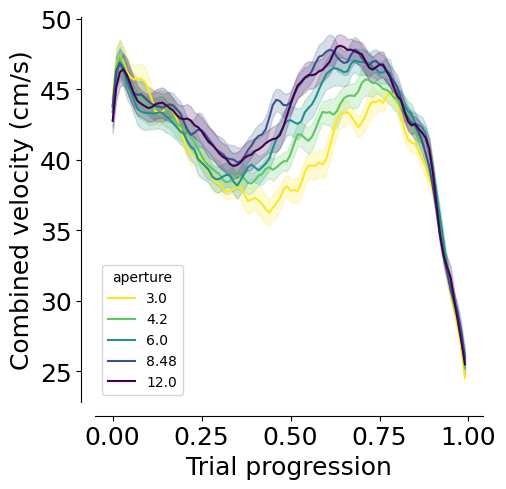

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = ax
mean_mouse = inter_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

mean_mouse.sort_values("aperture", inplace=True)
mean_mouse["aperture"] = mean_mouse.aperture.astype("str")

sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
#plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "figure4_multi_occluder_velocity.svg", transparent=False)

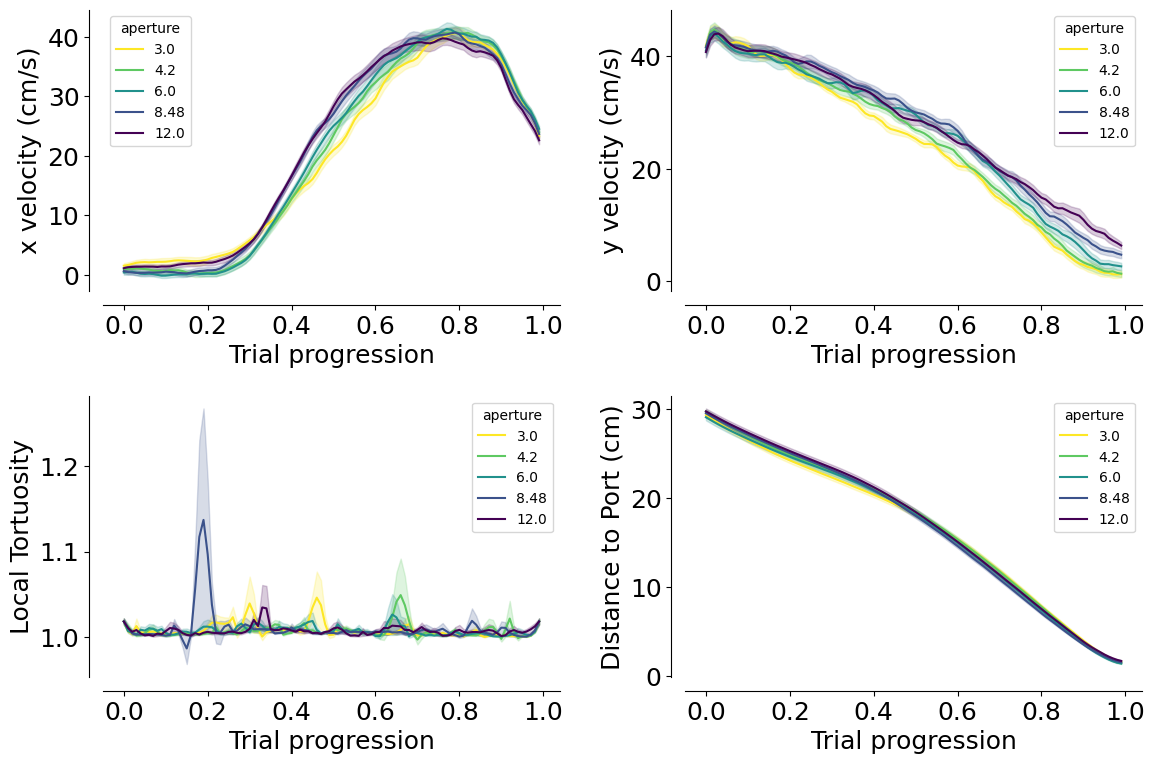

In [9]:
mean_mouse = inter_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else plotting.colors_multi_aperture
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure4_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

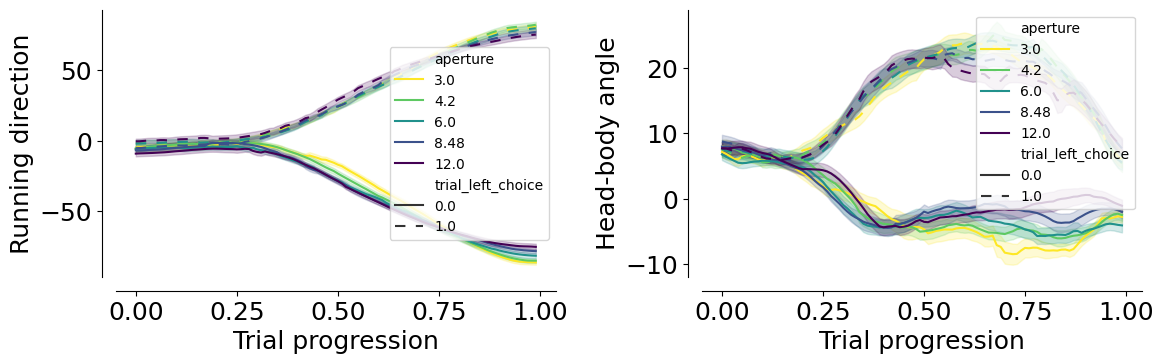

In [10]:
mean_mouse = inter_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

dash_styles = {
    mean_mouse.trial_left_choice.unique()[0]: "",         # Solid
    mean_mouse.trial_left_choice.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction", "Head-body angle"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        dashes=dash_styles,
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure4_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)

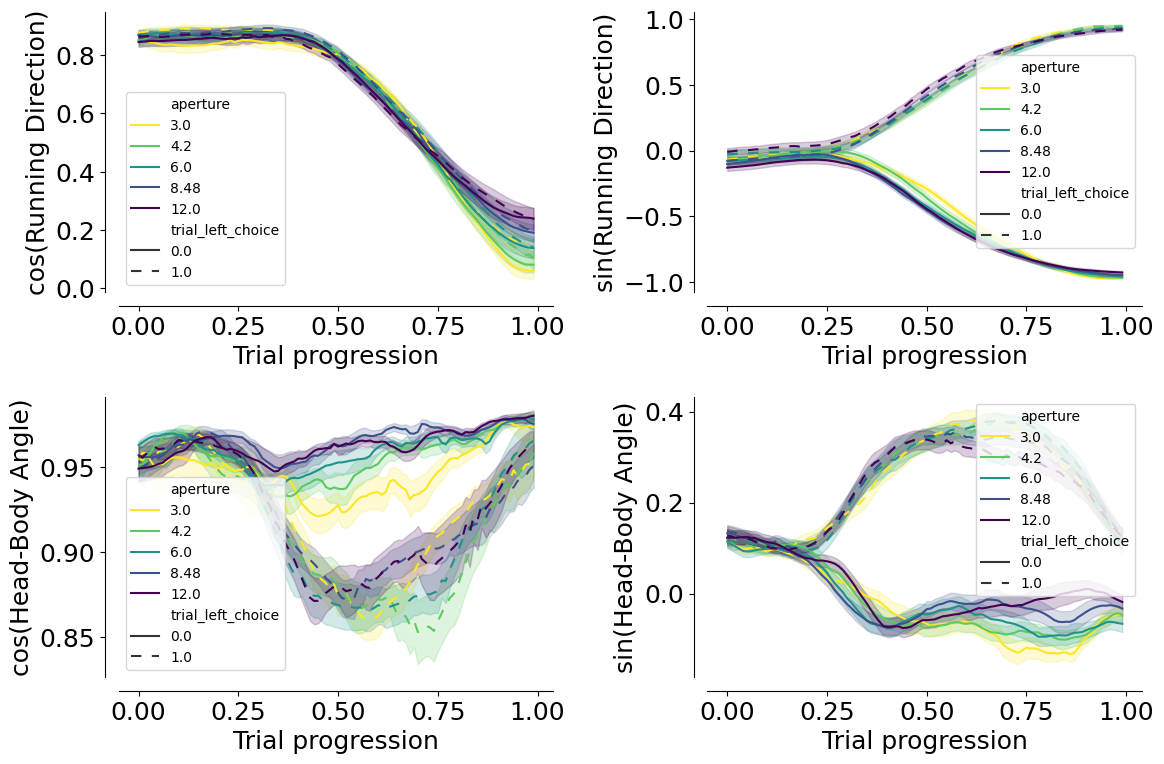

In [11]:
mean_mouse = inter_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

dash_styles = {
    mean_mouse.trial_left_choice.unique()[0]: "",         # Solid
    mean_mouse.trial_left_choice.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
        dashes=dash_styles,
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure4_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

In [13]:
inter_df["mouse_name"] = inter_df.dataset.str.split("_").str [0]

optimal_df =  inter_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  inter_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

In [14]:
optimal_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-01-15 10:13:55,857::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:55,857::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-01-15 10:13:55,869::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:55,869::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:55,937::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:55,937::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:55,944::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=0.3398984454919453, pvalue=0.7374767051545972, df=20)
3.0-6.0: TtestResult(statistic=0.7854369419313646, pvalue=0.4414034878481523, df=20)
3.0-8.48: TtestResult(statistic=4.274266787970241, pvalue=0.00037048397647746357, df=20)
4.2-6.0: TtestResult(statistic=0.7819487206802616, pvalue=0.4434042252864009, df=20)
4.2-8.48: TtestResult(statistic=3.611886535395763, pvalue=0.0017396329042580134, df=20)
6.0-8.48: TtestResult(statistic=1.8287175895021894, pvalue=0.08239533888306246, df=20)
12.0-3.0: TtestResult(statistic=-3.3485925673456034, pvalue=0.003198531952868006, df=20)
12.0-4.2: TtestResult(statistic=-3.2963176057887074, pvalue=0.0036067332145677177, df=20)
12.0-6.0: TtestResult(statistic=-2.8728325914647215, pvalue=0.009406887799398744, df=20)
12.0-8.48: TtestResult(statistic=-0.748351543716408, pvalue=0.4629583908910181, df=20)


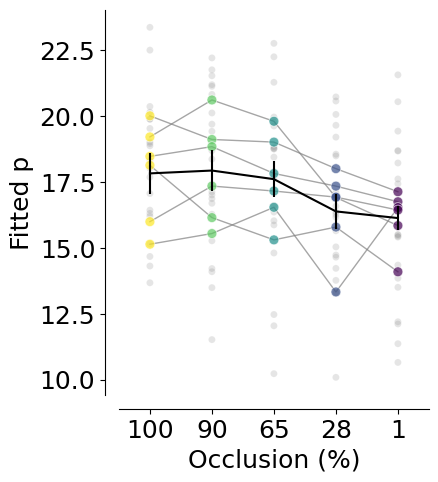

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

#optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]
counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_multi_aperture,
)
ax.invert_xaxis()

ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Fitted p")
ax.set_xlim(-0.5, 4.5)

ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure4_fitted_p.svg", transparent=True)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

2026-01-15 10:13:56,253::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:56,253::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:56,266::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:56,266::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:13:56,315::INFO::category.py::Using categorical un

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  6.0516 4.0000 80.0000 0.0003



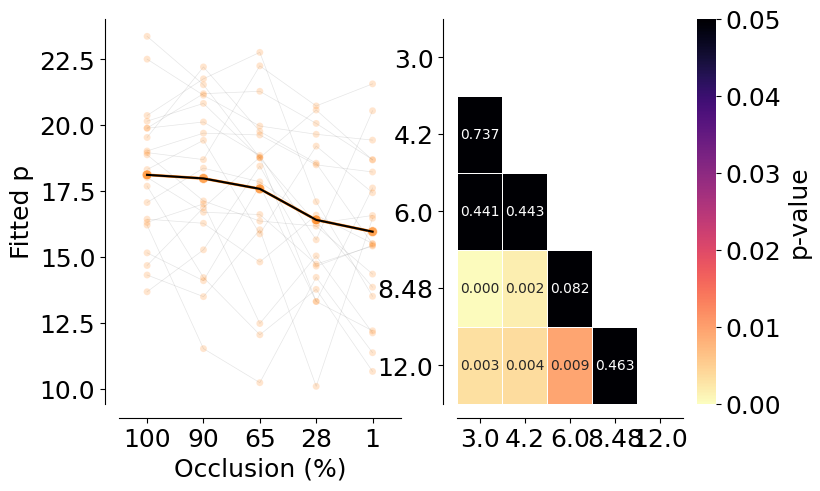

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

counts = (
    optimal_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_multi_aperture,
)
ax[0].invert_xaxis()

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Fitted p")
ax[0].set_xlim(-0.5, 4.5)

ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_performance_p_val(optimal_df,  y_var="optimal_p")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

print(AnovaRM(counts, depvar="count", subject="dataset", within=["aperture"]).fit())
plt.savefig(
    save_fig_path + "figure4_multi_occluder_fitted_p_per_lab.svg",
    transparent=True,
)

## Prediction model

In [17]:
key = {'task_type': 'multi_occl', "label_set_id": 5, "params_id": 1}

In [18]:
# Coefficients for dual occluder task
coef = (PredictionModel() & key).fetch1("coefficients")

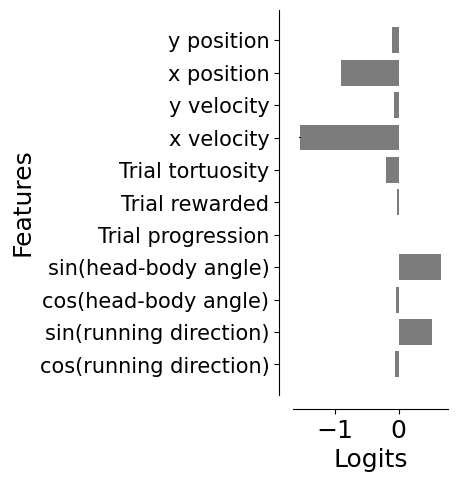

In [21]:
# Logits of the regression
model_labels, clean_labels = (LabelSet.Member * Label & key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(
    save_fig_path + "figure4_multi_occluder_model_logits.svg", transparent=False
)

In [22]:
prediction_df = pd.DataFrame((PredictionModel().SessionPrediction() & key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [23]:
df_model = prediction_df.merge(
    inter_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

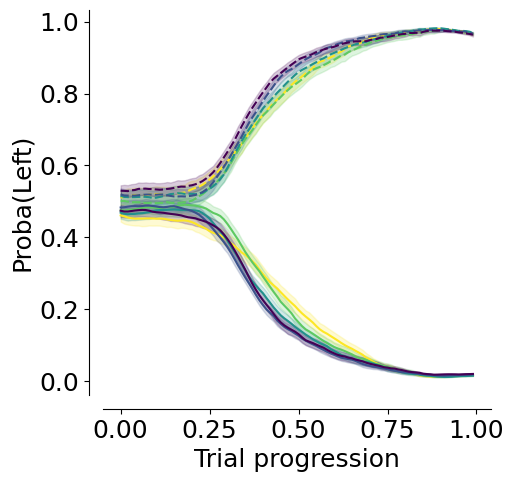

In [24]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (5, 5)      # Dashed
}

sns.lineplot(
    data=df_model,
    x="trial_length",
    y="proba_left",
    hue="aperture",
    style="trial_left_choice",
    palette=plotting.colors_multi_aperture,
    sort=False,
    alpha=1,
    ax=ax,
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(
    save_fig_path + "figure4_multi_dynamic_decision_variable_mean.svg", transparent=True
)

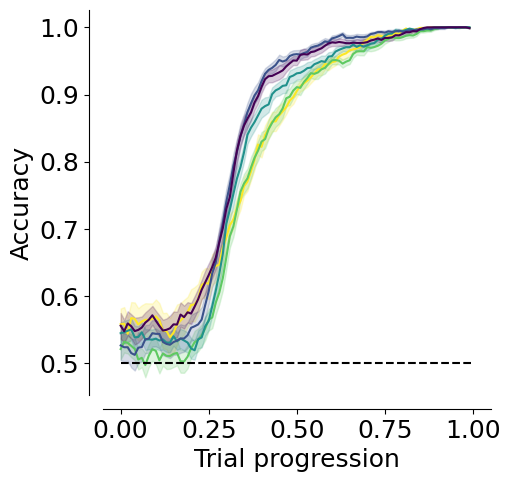

In [25]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

mean_mouse = df_model.groupby(["dataset", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["dataset", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax,
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
ax.hlines(0.5, 0, 1, color="black", linestyle="--")
plt.legend([], [], frameon=False)
plt.savefig(
    save_fig_path + "figure4_multi_occluder_model_accuracy.svg", transparent=False
)

In [26]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)  # Adjust bins as needed
df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                            Anova
                           F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------------
aperture                     6.3634   4.0000   80.0000 0.0002
trial_length_bin          1221.5872  49.0000  980.0000 0.0000
aperture:trial_length_bin    3.3738 196.0000 3920.0000 0.0000



## Get the decision points

In [30]:
decision_points = pd.DataFrame((DecisionPoints() & key & "threshold_uncertainty = 0.3").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]

In [31]:
decision_points["y"] = decision_points["y"].astype(float)

### Get distance to screen at decision point

2026-01-15 10:18:55,256::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:18:55,256::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:18:55,264::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:18:55,264::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:18:55,324::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=0.730541456566374, pvalue=0.4735310082590086, df=20)
-0.40754610572289174
3.0-6.0: TtestResult(statistic=2.5474194550897473, pvalue=0.019182713119716775, df=20)
-1.634746141616903
3.0-8.48: TtestResult(statistic=4.3182000112586385, pvalue=0.0003343431824681749, df=20)
-2.698985299644857
4.2-6.0: TtestResult(statistic=2.7241478894301796, pvalue=0.013067908485104992, df=20)
-1.2272000358940112
4.2-8.48: TtestResult(statistic=3.393835252601409, pvalue=0.0028820338161180442, df=20)
-2.291439193921965
6.0-8.48: TtestResult(statistic=1.7893309080471915, pvalue=0.08871755289107298, df=20)
-1.064239158027954
12.0-3.0: TtestResult(statistic=-5.386515413085394, pvalue=2.8454411837915644e-05, df=20)
3.478834230602171
12.0-4.2: TtestResult(statistic=-5.320677190203069, pvalue=3.303404975226364e-05, df=20)
3.0712881248792794
12.0-6.0: TtestResult(statistic=-2.988211626145563, pvalue=0.007266082610504921, df=20)
1.8440880889852682
12.0-8.48: TtestResult(statistic=-1.73

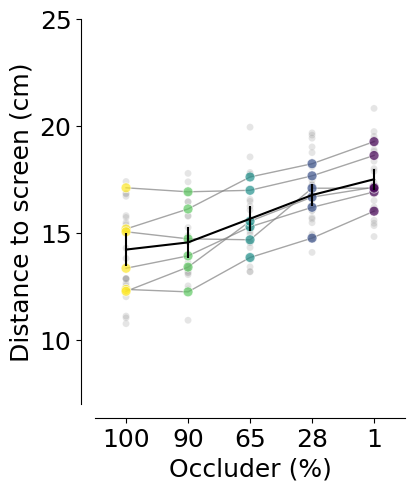

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.set_ylim(7, 25)
ax.set_xlim(-0.5, 4.5)
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure4_multi_occluder_decision_points_distance.svg",
    transparent=True,
)

In [33]:
decision_points["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-01-15 10:19:06,788::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:19:06,788::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:19:06,796::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:19:06,796::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 10:19:06,821::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=1.6033881571647393, pvalue=0.12452516796367886, df=20)
-0.40754610572288996
3.0-6.0: TtestResult(statistic=4.147061150967732, pvalue=0.0004987932346226274, df=20)
-1.6347461416168994
3.0-8.48: TtestResult(statistic=7.220766081772231, pvalue=5.467366146428169e-07, df=20)
-2.6989852996448533
4.2-6.0: TtestResult(statistic=4.710225703651042, pvalue=0.00013420065195211847, df=20)
-1.2272000358940094
4.2-8.48: TtestResult(statistic=7.5233281709901805, pvalue=2.9713343545203404e-07, df=20)
-2.2914391939219634
6.0-8.48: TtestResult(statistic=4.475167525374225, pvalue=0.0002318037381540663, df=20)
-1.064239158027954
12.0-3.0: TtestResult(statistic=-9.604989486402694, pvalue=6.203389615717057e-09, df=20)
3.4788342306021676
12.0-4.2: TtestResult(statistic=-10.157635124418496, pvalue=2.430540218338684e-09, df=20)
3.0712881248792776
12.0-6.0: TtestResult(statistic=-7.4513726845430455, pvalue=3.4312082425671884e-07, df=20)
1.8440880889852682
12.0-8.48: TtestResult(sta

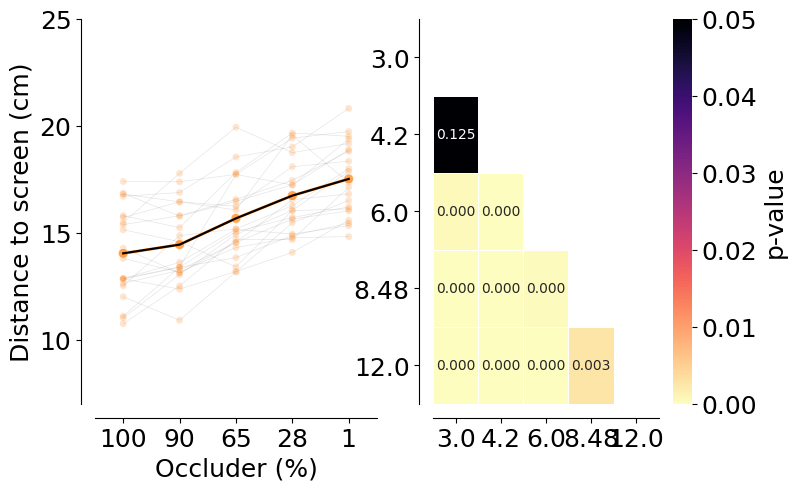

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].set_ylim(7, 25)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_performance_p_val(decision_points,  y_var="y")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

decision_points_anova = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
print(AnovaRM(decision_points_anova, depvar="y", subject="dataset", within=["aperture"]).fit())


plt.savefig(
    save_fig_path + "figure4_multi_occluder_decision_points_distance_per_lab.svg",
    transparent=True,
)

### Compare thresholds

In [35]:
all_decision_points = pd.DataFrame((DecisionPoints()).fetch(as_dict=True))
all_decision_points = all_decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
all_decision_points["mouse_name"] = all_decision_points.dataset.str.split("_").str[0]

In [36]:
all_decision_points.dropna(subset=["y"], inplace=True)
all_decision_points["distance_to_screen"] = np.abs(all_decision_points["y"] - 27)

In [37]:
filtered_df = all_decision_points[all_decision_points["aperture"].isin([3.0, 12.0])]
grouped = filtered_df.groupby(["mouse_name", "dataset", "threshold_uncertainty", "aperture"])["distance_to_screen"].mean().unstack("aperture")

grouped["diff"] = grouped[12.0] - grouped[3.0]
result_df = grouped.reset_index()

2026-01-15 12:29:58,866::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 12:29:58,866::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 12:29:58,879::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-01-15 12:29:58,879::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 12:29:58,939::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 12:29:58,939::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 12:29:58,945::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-15 12:29:58,945::INFO::category.py::Using categorical un

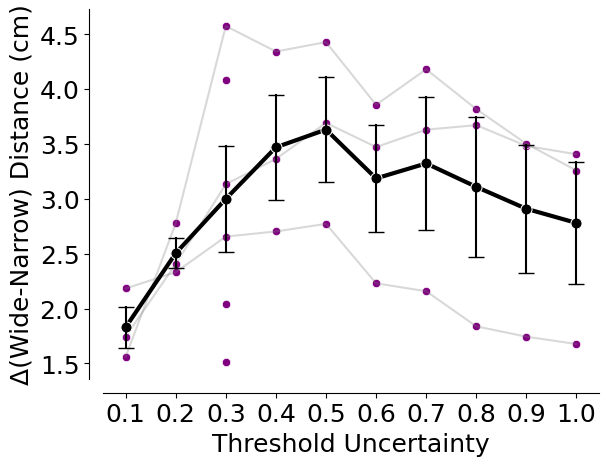

In [38]:
# Average sessions for each mouse first
mouse_averages = result_df.groupby(["mouse_name", "threshold_uncertainty"], as_index=False)["diff"].mean()
session_averages = result_df.groupby(["threshold_uncertainty"], as_index=False)["diff"].mean()

# Plot individual mouse lines (gray)
sns.lineplot(
    data=mouse_averages, 
    x="threshold_uncertainty", 
    y="diff", 
    units="mouse_name", 
    estimator=None, 
    color="gray", 
    alpha=0.3
)

# Plot individual mouse points
sns.scatterplot(
    data=mouse_averages, 
    x="threshold_uncertainty", 
    y="diff", 
    color="purple",
    
)

# Plot global average + SEM (black)
sns.lineplot(
    data=mouse_averages, 
    x="threshold_uncertainty", 
    y="diff", 
    errorbar="se", 
    color="black", 
    linewidth=3, 
    marker="o",
    markersize=8,
    err_style="bars", 
    err_kws={'capsize': 6}
)

plt.ylabel("Δ(Wide-Narrow) Distance (cm)")
plt.xlabel("Threshold Uncertainty")
sns.despine(offset=10)